In [1]:
import pandas as pd  
from pandas import Series, DataFrame 
import uproot 
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import comb
from scipy.stats import chi2
from scipy.special import comb
from scipy.optimize import lsq_linear
import sys
from plot_tools import *
from customStats import *
#import tools
import common_tools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
# from selection_cuts import selection_nominal
import mplhep as hep
from sklearn.model_selection import train_test_split
plt.style.use(hep.style.CMS)
plt.rcParams['figure.figsize'] = [10,8]
plt.rcParams['font.size'] = 24
plt.figure()
plt.close()
plt.rcParams.update({'figure.figsize':[10,8]})
plt.rcParams.update({'font.size':24})
import tensorflow as tf
import math
import zfit
from zfit import z
import xgboost as xgb
from scipy.interpolate import make_interp_spline
# from loadCutXGB import load_and_cutXGBclfs
from scipy.special import comb
from scipy.optimize import lsq_linear
zfit.settings.set_verbosity(0)
import json
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Oculta los mensajes de INFO y WARNING
from PDFs import *
from utils_efficiency import *
import itertools
from utils_fits import *
from matplotlib.gridspec import GridSpec


2026-03-19 20:38:38.741569: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 20:38:38.927160: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 20:38:39.507994: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/ghcp/miniconda3/envs/haza_wokr_env/lib/python3.8/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress th

#  CARGA DE DATOS

In [3]:
import uproot
import pandas as pd

# --- RUTAS DE ARCHIVOS ---
f_gen = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/GenLevel_Angular_Merged.root"
f_gen_filtered = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/GenLevel_Angular_Merged_Filtered.root"
f_reco_gen = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/efficiencies/datasets/RecoGenV2_Angular_Merged.root"  
x_gboost_cut = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/BdtoK0smumu-20251110T171511Z-1-001/MyReweiting/ResultsB0_2022/AntiRadVeto_MC_NoRes_2022_Era1_v0_XGBoost_fom_cut_BDT.root"

vars_gen_to_load = ["gen_cosThetaK", "gen_cosThetaL", "gen_phi", "q2Gen"]
vars_reco_to_load = ["CosThetaK_best", "CosThetaL_best", "Phi_best", "massJ"] 
vars_xgboost_to_load = ["CosThetaK", "CosThetaL", "Phi", "massB_test", "massJ", "TotalWeight"] 

# --- CARGA DE DATOS ---
#Gen NO filt
genNFtr = uproot.open(f_gen)['ntuple'].arrays(vars_gen_to_load, library='pd')
print(f"1. Gen Non-Filtered (genNFtr) cargado: {len(genNFtr)} eventos")
# Gen Filtered
genFtr = uproot.open(f_gen_filtered)['ntuple'].arrays(vars_gen_to_load, library='pd')
print(f"2. Gen Filtered (genFtr) cargado: {len(genFtr)} eventos")
# Reco Gen Level
recoGen = uproot.open(f_reco_gen)['ntuple'].arrays(vars_reco_to_load, library='pd')
print(f"3. Reco Gen Level Denom (recoGen) cargado: {len(recoGen)} eventos")
# Final selection 
recoFtr = uproot.open(x_gboost_cut)['treeBd'].arrays(vars_xgboost_to_load, library='pd')
print(f"4. Reco Final (recoFtr) cargado: {len(recoFtr)} eventos")



1. Gen Non-Filtered (genNFtr) cargado: 11589148 eventos
2. Gen Filtered (genFtr) cargado: 307688 eventos
3. Reco Gen Level Denom (recoGen) cargado: 6298017 eventos
4. Reco Final (recoFtr) cargado: 900424 eventos


In [4]:

recoFtr["q2"] = recoFtr["massJ"]**2 
recoGen["q2Gen"] = recoGen["massJ"]**2  

GenNFlt = genNFtr.copy()     
GenFlt  = genFtr.copy()       

RecoGenFlt = recoGen.copy()             
mask_mass = (recoFtr["massB_test"] > 5.0) & (recoFtr["massB_test"] < 5.6)
Reco = recoFtr[mask_mass].copy()

eff_Gen, obs_Gen = train_test_split(GenNFlt, test_size=0.03, random_state=549)
eff_GenFtr, obs_GenFtr = train_test_split(GenFlt, test_size=0.1, random_state=22)
eff_RecoGenFtr, obs_RecoGenFtr = train_test_split(RecoGenFlt, test_size=0.1, random_state=22)
eff_RecoFtr, obs_RecoFtr = train_test_split(Reco, test_size=0.5, random_state=549)

a1 = np.array(obs_Gen["gen_cosThetaL"])
a2 = np.array(obs_Gen["gen_cosThetaK"])
a3 = np.array(obs_Gen["gen_phi"])

angles = np.array([a1, a2, a3])
valid_observations_mask = ~np.isnan(angles).any(axis=0)
filtered_data = angles[:, valid_observations_mask]

In [5]:
print("Numero de eventes GEN",len(obs_Gen))
print("Numero de eventes GEN Filtered",len(obs_GenFtr))
print("Numero de eventes Reco Gen filtered",len(obs_RecoGenFtr))
print("Numero de eventes Reco Filtered",len(obs_RecoFtr))


Numero de eventes GEN 347675
Numero de eventes GEN Filtered 30769
Numero de eventes Reco Gen filtered 629802
Numero de eventes Reco Filtered 450212


# FUNCTIONS

In [6]:
import itertools
import os
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
import mplhep as hep


def load_boundary_data(boundary_file):

    if os.path.exists(boundary_file):
        print(f">>> Datos de fronteras cargados desde: {boundary_file}")
        return np.load(boundary_file, allow_pickle=True)
    else:
        print(f">>> No se encontró {boundary_file}. Se graficará sin fronteras.")
        return None

def setup_output_directories(out_dir):
    paths = {
        "trans": os.path.join(out_dir, "contours_transformed"),
        "phys_zoom": os.path.join(out_dir, "contours_physical", "Zoom"),
        "phys_full": os.path.join(out_dir, "contours_physical", "Full")
    }
    for path in paths.values():
        os.makedirs(path, exist_ok=True)
    return paths

def run_minuit_fit(pdf, data, fit_params_list, result_zfit):

    nll = zfit.loss.UnbinnedNLL(model=pdf, data=data)
    p_names = [p.name for p in fit_params_list]
    start_vals = {p.name: result_zfit.params[p]['value'] for p in fit_params_list}
    
    # def nll_wrap(*args):
    #     for p, val in zip(fit_params_list, args):
    #         p.set_value(val)
    #     return nll.value()
    def nll_wrap(*args):
        for p, val in zip(fit_params_list, args):
            p.set_value(val)
        try:
            return float(nll.value())
        except Exception:
            return 1e10 # Penalización gigante si algo falla numéricamente

    m = Minuit(nll_wrap, name=p_names, *[start_vals[n] for n in p_names])
    m.errordef = 0.5  # 1 sigma (-log(L) = 0.5)
    m.migrad()
    m.minos()
    
    return m, start_vals

# ==============================================================================
# PLOTS
# ==============================================================================

def plot_transformed_space(x_cont, y_cont, bf_x, bf_y, err_x, err_y, name_x, name_y, binN, out_path):

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(x_cont, y_cont, color='blue', linewidth=2, label=r'$1\sigma$ Countourn')
    ax.plot(bf_x, bf_y, marker='x', color='red', markersize=14, linestyle='None', label='Best Fit')
    
    x_min, x_max = bf_x + err_x.lower, bf_x + err_x.upper
    y_min, y_max = bf_y + err_y.lower, bf_y + err_y.upper
    ax.axvline(x_min, color='red', linestyle='--', alpha=0.5, label='Error MINOS')
    ax.axvline(x_max, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y_min, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y_max, color='red', linestyle='--', alpha=0.5)
    
    # =========================================================================
    # NUEVO: Calcular los límites con un margen del 40% para evitar solapamiento
    # =========================================================================
    x_min_cont, x_max_cont = np.min(x_cont), np.max(x_cont)
    y_min_cont, y_max_cont = np.min(y_cont), np.max(y_cont)
    
    mx = (x_max_cont - x_min_cont) * 0.4
    my = (y_max_cont - y_min_cont) * 0.4
    
    ax.set_xlim(x_min_cont - mx, x_max_cont + mx)
    ax.set_ylim(y_min_cont - my, y_max_cont + my)
    # =========================================================================
    
    ax.set_xlabel(name_x, fontsize=24)
    ax.set_ylabel(name_y, fontsize=24)
    hep.cms.label(ax=ax, data=False, year=2022, loc=0)
    
    err_x_up, err_x_down = err_x.upper, abs(err_x.lower)
    err_y_up, err_y_down = err_y.upper, abs(err_y.lower)
    
    res_text = (name_x+rf"$ = {bf_x:.4f}^{{+{err_x_up:.4f}}}_{{-{err_x_down:.4f}}}$" + "\n" + name_y+ rf"$= {bf_y:.4f}^{{+{err_y_up:.4f}}}_{{-{err_y_down:.4f}}}$")
    
    ax.text(0.05, 0.93, res_text, transform=ax.transAxes, fontsize=16, va='top', ha='left', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))
    ax.legend(loc='upper right', frameon=True, framealpha=0.8, edgecolor='white', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(os.path.join(out_path, f"contour_{name_x}_{name_y}_{binN}.png"), dpi=300, bbox_inches='tight')
    plt.close(fig)
    
def plot_physical_space(x_cont, y_cont, bf_x, bf_y, name_x, name_y, binN, boundary_res, view_mode, out_path):

    x_min_cont, x_max_cont = np.min(x_cont), np.max(x_cont)
    y_min_cont, y_max_cont = np.min(y_cont), np.max(y_cont)
    err_x_up, err_x_down = x_max_cont - bf_x, bf_x - x_min_cont
    err_y_up, err_y_down = y_max_cont - bf_y, bf_y - y_min_cont
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # fronteras
    bx, bmin, bmax = boundary_res['x'], boundary_res['min'], boundary_res['max']
    ax.plot(bx, bmin, color='b', linestyle='--', linewidth=1.5, alpha=0.3, zorder=1)
    ax.plot(bx, bmax, color='b', linestyle='--', linewidth=1.5, alpha=0.3, zorder=1)
    ax.fill_between(bx, bmin, bmax, facecolor="none", edgecolor="red", hatch='///', alpha=0.2, zorder=1, label='Physical Allowed Region')

    # Contorno, best fit y errores
    ax.plot(x_cont, y_cont, color='green', linestyle='-', linewidth=2, label=r'$1\sigma$ Contour', zorder=5)
    ax.plot(bf_x, bf_y, marker='x', color='red', markersize=14, linestyle='None', label='Best fit', zorder=10)
    ax.axvline(x_min_cont, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.axvline(x_max_cont, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.axhline(y_min_cont, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.axhline(y_max_cont, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.set_xlabel(name_x, fontsize=24)
    ax.set_ylabel(name_y, fontsize=24)
    hep.cms.label(data=False, year=2022, loc=0, ax=ax)
    res_text = (name_x+rf"$= {bf_x:.4f}^{{+{err_x_up:.4f}}}_{{-{err_x_down:.4f}}}$" + "\n" + name_y + rf"$= {bf_y:.4f}^{{+{err_y_up:.4f}}}_{{-{err_y_down:.4f}}}$")
    
    if view_mode == 'Zoom':
        ax.text(0.05, 0.93, res_text, transform=ax.transAxes, fontsize=16, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))
        mx, my = (x_max_cont - x_min_cont) * 0.4, (y_max_cont - y_min_cont) * 0.4
        ax.set_xlim(x_min_cont - mx, x_max_cont + mx)
        ax.set_ylim(y_min_cont - my, y_max_cont + my)

    else: # Full View
        ax.text(0.05, 0.93, res_text, transform=ax.transAxes, fontsize=14, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        if boundary_res is not None:
            ax.set_xlim(0 if name_x == 'FL' else -1.05, 1 if name_x == 'FL' else 1.05)
            ax.set_ylim(0 if name_y == 'FL' else -1.05, 1 if name_y == 'FL' else 1.05)
        else:
            ax.set_xlim(-0.1 if name_x == 'FL' else -1.1, 1.1)
            ax.set_ylim(-0.1 if name_y == 'FL' else -1.1, 1.1)
            
    ax.legend(loc='upper right', fontsize=14, frameon=True, framealpha=0.8, edgecolor='white')        
    ax.grid(True, linestyle=':', alpha=0.4)  
    plt.savefig(os.path.join(out_path, f"Phys_{name_x}_vs_{name_y}_{binN}_{view_mode}.png"), bbox_inches='tight', dpi=300)
    plt.close(fig)

def generate_contours(pdf, data, fit_params_list, result_zfit, binN, out_dir):

    hep.style.use("CMS")    
    boundary_file = "/home/ghcp/Documentos/CINVESTAV/ANALISYS_B0tomumuKstar/angular/notebooks/Plots/BoundaryData/theoretical_boundaries.npz"
    boundary_data = load_boundary_data(boundary_file)
    paths = setup_output_directories(out_dir)
    
    m, start_vals = run_minuit_fit(pdf, data, fit_params_list, result_zfit)    
    param_pairs = list(itertools.combinations(fit_params_list, 2))
    
    for p1, p2 in param_pairs:
        print(f"  -> Extrayendo contorno 2D: {p1.name} vs {p2.name}...")

        # Obtener valores del ajuste para el par actual
        err_p1, err_p2 = m.merrors[p1.name], m.merrors[p2.name]
        bf_1, bf_2 = m.values[p1.name], m.values[p2.name]
        obs_name1 = p1.name.split('_')[0].replace('r', '')
        obs_name2 = p2.name.split('_')[0].replace('r', '')
        
        # Calcular contorno en el espacio de ajuste
        contour = m.mncontour(p1.name, p2.name, cl=0.3935, size=50)
        if len(contour) == 0:
            print(f"No se genero el contorno {p1.name} vs {p2.name}")
            continue # Salta a la siguiente iteración del loop
        x_contour, y_contour = zip(*contour)
        
        # Transformar a espacio físico
        phys_x_contour, phys_y_contour = [], []
        for cx, cy in zip(x_contour, y_contour):
            r_array = [cx if p == p1 else (cy if p == p2 else start_vals[p.name]) for p in fit_params_list]
            phys_dict = apply_transformation_equations(*r_array)
            phys_x_contour.append(phys_dict.get(obs_name1, 0.0))
            phys_y_contour.append(phys_dict.get(obs_name2, 0.0))

        # Best fit en el espacio físico
        best_phys_dict = apply_transformation_equations(*[start_vals[p.name] for p in fit_params_list])
        bf_phys_1, bf_phys_2 = best_phys_dict.get(obs_name1, 0.0), best_phys_dict.get(obs_name2, 0.0)

        # Extraer fronteras específicas para este par
        boundary_res = None
        if boundary_data is not None:
            key_pair = f"{obs_name1}_vs_{obs_name2}"
            if key_pair in boundary_data:
                boundary_res = boundary_data[key_pair].item()

        plot_transformed_space(x_contour, y_contour, bf_1, bf_2, err_p1, err_p2, p1.name, p2.name, binN, paths["trans"])
        plot_physical_space(phys_x_contour, phys_y_contour, bf_phys_1, bf_phys_2, obs_name1, obs_name2, binN, boundary_res, "Zoom", paths["phys_zoom"])
        plot_physical_space(phys_x_contour, phys_y_contour, bf_phys_1, bf_phys_2, obs_name1, obs_name2, binN, boundary_res, "Full", paths["phys_full"])


class FullAngular_Physical_PDF_projection(zfit.pdf.BasePDF):
    def __init__(self, obs, FL, S3, S9, AFB, S4, S7, S5, S8, name="FullAngular_Physical_PDF"):
        params = {'FL': FL, 'S3': S3, 'S9': S9, 'AFB': AFB, 'S4': S4, 'S7': S7, 'S5': S5, 'S8': S8}
        super().__init__(obs, params, name=name)
    
    def _unnormalized_pdf(self, x):
        vars_list = z.unstack_x(x)
        cos_l = vars_list[0]
        cos_k = vars_list[1]
        phi   = vars_list[2]
        
        sin_k = tf.sqrt(1.0 - cos_k**2)
        sin_l = tf.sqrt(1.0 - cos_l**2)
        sin2_k = sin_k**2
        cos2_k = cos_k**2
        sin2_l = sin_l**2
        
        cos2l_term = 2.0 * cos_l**2 - 1.0
        sin2l_term = 2.0 * sin_l * cos_l
        sin2k_term = 2.0 * sin_k * cos_k
        
        cos_phi = tf.cos(phi)
        sin_phi = tf.sin(phi)
        cos2_phi = tf.cos(2.0 * phi)
        sin2_phi = tf.sin(2.0 * phi)

        FL = self.params['FL']
        S3 = self.params['S3']
        S9 = self.params['S9']
        AFB = self.params['AFB']
        S4 = self.params['S4']
        S7 = self.params['S7']
        S5 = self.params['S5']
        S8 = self.params['S8']
        
        term1 = 0.75 * (1.0 - FL) * sin2_k
        term2 = FL * cos2_k
        term3 = 0.25 * (1.0 - FL) * sin2_k * cos2l_term
        term4 = -1.0 * FL * cos2_k * cos2l_term
        term5 = S3 * sin2_k * sin2_l * cos2_phi
        term6 = S4 * sin2k_term * sin2l_term * cos_phi
        term7 = S5 * sin2k_term * sin_l * cos_phi
        term8 = (4.0/3.0) * AFB * sin2_k * cos_l
        term9 = S7 * sin2k_term * sin_l * sin_phi
        term10 = S8 * sin2k_term * sin2l_term * sin_phi
        term11 = S9 * sin2_k * sin2_l * sin2_phi
        
        pdf = term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9 + term10 + term11
        pdf = tf.math.maximum(pdf, 1e-10)
        return pdf

    # zfit ahora usará integración numérica por defecto, lo que permite
    # calcular proyecciones (integrales parciales) correctamente.

def _calc_chi2_standardized(obs, exp, n_params):
    """
    Calcula el Chi2 de Neyman, grados de libertad (ndof), p-value y pulls.
    Lógica basada en la aproximación de Neyman:
    """
    # 1. Asegurar que trabajamos con arrays de numpy flotantes
    obs = np.asarray(obs, dtype=np.float64)
    exp = np.asarray(exp, dtype=np.float64)
    
    # Verificación de integridad básica
    if obs.shape != exp.shape:
        raise ValueError(f"Dimensión incorrecta: Obs {obs.shape} != Exp {exp.shape}")

    # 2. Máscara: Neyman requiere Observados > 0
    mask = obs > 0
    obs_m = obs[mask]
    exp_m = exp[mask]
    
    # 3. Cálculo de Chi2 (Neyman)
    # Fórmula: sum( (O - E)^2 / O )
    terms = np.square(obs_m - exp_m) / obs_m
    chi2_val = np.sum(terms)
    
    # 4. Grados de Libertad (NDOF)
    # NDOF = N_bins_con_datos - N_parametros
    n_bins_w_data = np.sum(mask)
    ndof = n_bins_w_data - n_params
    
    # 5. Cálculo del p-value con seguridad para NDOF <= 0
    if ndof > 0:
        p_val = 1 - stats.chi2.cdf(chi2_val, ndof)
    else:
        # Si tienes más parámetros que datos, el ajuste está indeterminado
        p_val = np.nan 
        print(f"Advertencia: NDOF <= 0 ({ndof}). Revisa tu binning o modelo.")

    # 6. Cálculo de Pulls
    # Inicializamos en cero para mantener la forma original del array
    pulls = np.zeros_like(obs)
    # Pull = (Obs - Exp) / error_obs
    # Solo calculamos donde mask es True para evitar warnings de división por cero
    pulls[mask] = (obs_m - exp_m) / np.sqrt(obs_m)
    
    return chi2_val, ndof, p_val, pulls

def plot_analytical_projections_cms(sampler, phys_params_dict, folder_out="Plots/Analytic_Projections", n_bins=30):
    """
    Genera proyecciones con estilo CMS usando zfit, pero estandarizando
    el cálculo de Chi2/ndof y Pulls con la función _calc_chi2_standardized.
    """
    if not os.path.exists(folder_out):
        os.makedirs(folder_out)

    obs_space = sampler.space
    observables = obs_space.obs  
    
    # 1. Instanciar la PDF Física con los parámetros del Best Fit
    print(f">>> Instanciando PDF física para proyecciones...")
    pdf_model = FullAngular_Physical_PDF_projection(
        obs=obs_space,
        **phys_params_dict 
    )

    # Etiquetas LaTeX para los ejes
    latex_labels = {
        observables[0]: r'$\cos(\theta_l)$',
        observables[1]: r'$\cos(\theta_K)$',
        observables[2]: r'$\phi$'
    }

    # Mapa de parámetros libres por variable para el cálculo correcto de NDOF
    # Índice 0 (CosL): 2 params (FL, AFB)
    # Índice 1 (CosK): 1 param (FL)
    # Índice 2 (Phi) : 2 params (S3, S9)
    n_params_map = {0: 2, 1: 1, 2: 2}

    # Total de eventos (para escalar la PDF)
    n_total = sampler.n_events.numpy()

    for obs_name in observables:
        print(f"--- Procesando plot CMS para: {obs_name} ---")
        
        # A. Crear la PDF Proyectada (integrando las otras variables)
        vars_to_integrate = [var for var in observables if var != obs_name]
        limits_integration = obs_space.with_obs(vars_to_integrate)
        pdf_proj = pdf_model.create_projection_pdf(limits=limits_integration)
        
        # B. Preparar Datos (Histograma)
        idx = observables.index(obs_name)
        data_column = sampler.unstack_x()[idx]
        
        if hasattr(data_column, "numpy"):
            data_np = data_column.numpy()
        else:
            data_np = np.array(data_column)
            
        counts, bin_edges = np.histogram(data_np, bins=n_bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        y_err_data = np.sqrt(counts)
        
        # C. Calcular Modelo
        lower, upper = obs_space.with_obs(obs_name).limit1d
        
        # C.1 Para el plot suave (alta resolución)
        x_fine = np.linspace(lower, upper, 400)
        y_smooth_density = pdf_proj.pdf(x_fine).numpy()
        y_smooth_counts = y_smooth_density * n_total * bin_width
        
        # C.2 Para Chi2 y Pulls (evaluado en el centro del bin - Observado vs Esperado)
        # Nota: Usamos el valor en el centro como aproximación de la integral del bin para zfit
        y_model_at_centers_density = pdf_proj.pdf(bin_centers).numpy()
        y_model_at_centers = y_model_at_centers_density * n_total * bin_width
        
        # D. ESTADÍSTICA ESTANDARIZADA
        # ==============================================================================
        # Aquí conectamos con tu función estandarizada para garantizar consistencia.
        # Recuperamos el número de parámetros libres para esta variable específica
        n_params_curr = n_params_map.get(idx, 1) 
        
        # Llamada a la función externa que ya definiste
        chi2_val, ndof, p_val, pulls = _calc_chi2_standardized(
            obs=counts, 
            exp=y_model_at_centers, 
            n_params=n_params_curr
        )
        chi2_red = chi2_val / ndof
        # ==============================================================================

        # ====== PLOTTING ESTILO CMS (Sin cambios mayores) ======
        fig = plt.figure(figsize=(9, 9))
        gs = GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
        ax0 = fig.add_subplot(gs[0])
        ax1 = fig.add_subplot(gs[1])

        # --- Panel Superior (Datos + Modelo) ---
        ax0.errorbar(bin_centers, counts, yerr=y_err_data, xerr=bin_width/2.0, 
                     fmt='ks', markersize=4, elinewidth=1, capsize=2, label='Toy (data)')

        ax0.plot(x_fine, y_smooth_counts, '-', linewidth=2, label='Analytical PDF', color='b')
        
        # Límites dinámicos
        max_data = np.max(counts + y_err_data)
        max_model = np.max(y_smooth_counts)
        y_max_plot = max(max_data, max_model)
        ax0.set_ylim(0, y_max_plot * 1.5)
        
        ax0.set_xlim(lower, upper)
        ax0.set_xticklabels([]) 
        ax0.set_ylabel(f'Events / {bin_width:.2f}', fontsize=16)
        ax0.grid(True, alpha=0.2)
        ax0.legend(loc='upper right', fontsize=13, frameon=False, bbox_to_anchor=(0.98, 0.88))

        hep.cms.label(data=False, loc=0, ax=ax0, rlabel="13 TeV")

        # --- Caja de Texto con Estadísticas ---
        FL_val = phys_params_dict.get('FL', 0)
        AFB_val = phys_params_dict.get('AFB', 0)
        S3_val = phys_params_dict.get('S3', 0)
        S9_val = phys_params_dict.get('S9', 0)

        # Usamos p-value simple para evitar error de LaTeX en backend
        param_text = (
            rf'$F_L = {FL_val:.3f}$' + '\n' +
            rf'$A_{{FB}} = {AFB_val:.3f}$' + '\n' +
            rf'$S_3 = {S3_val:.3f}$' + '\n' +
            rf'$S_9 = {S9_val:.3f}$' + '\n' +
            r'----------------' + '\n' + 
            rf'$\chi^2/\mathrm{{ndof}} = {chi2_val:.1f}/{ndof} = {chi2_red:.2f}$' + '\n' +
            rf'$p$-value = {p_val:.3g}'
        )

        ax0.text(0.05, 0.92, param_text, transform=ax0.transAxes, fontsize=12, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#dddddd'))

        # --- Panel Inferior (Pulls) ---
        ax1.errorbar(bin_centers, pulls, 
                     yerr=1.0,           
                     xerr=0,             
                     fmt='ks',           
                     markersize=3,       
                     elinewidth=1.0,     
                     capsize=0)          
        
        ax1.axhline(0, color='black', linewidth=1.0, linestyle='-')
        ax1.axhline(3, color='gray', linestyle=':', linewidth=1, alpha=0.8) 
        ax1.axhline(-3, color='gray', linestyle=':', linewidth=1, alpha=0.8)
        
        ax1.fill_between([lower, upper], -1, 1, color='yellow', alpha=0.1) 
        ax1.fill_between([lower, upper], -2, 2, color='green', alpha=0.05) 

        xlabel = latex_labels.get(obs_name, obs_name)
        ax1.set_xlabel(xlabel, fontsize=16)
        ax1.set_ylabel(r'Pull $(\sigma)$', fontsize=13)
        ax1.set_xlim(lower, upper)
        ax1.set_ylim(-4.9, 4.9)
        ax1.grid(True, alpha=0.2)

        ax0.tick_params(axis='both', which='major', labelsize=14) 
        ax1.tick_params(axis='both', which='major', labelsize=14)

        outname = os.path.join(folder_out, f"CMS_Proj_{obs_name}.png")
        plt.savefig(outname, bbox_inches='tight', dpi=200)
        plt.close(fig)
        print(f"    -> Gráfica guardada: {outname} (Chi2/ndof={chi2_red:.2f})")

    print(">>> Todas las proyecciones estilo CMS generadas.")





# GEN FIT PHYSICAL SPACE

In [ ]:
#%%capture data_gen_phy_fit
q2_bins = {"bin1":[1.1, 2.0],"bin2": [2.0, 4.0],"bin3":[4.0, 6.0], "bin4":[6.0, 7.0], "bin5":[7.0, 8.0],"bin7":[11.0, 12.5], "bin9":[15.0, 17.0], "bin10":[17.0, 23.0]}

for binN in q2_bins.keys():
    print(f"\n{'='*60}\nProcesando {binN} con rango q2: {q2_bins[binN]}\n{'='*60}")

    # ======================================================
    # CONFIGURACIÓN DEL ESPACIO 
    # ======================================================
    cos_l = zfit.Space('cos_l', limits=(-1, 1))
    cos_k = zfit.Space('cos_k', limits=(-1, 1))
    phi   = zfit.Space('phi',   limits=(-np.pi, np.pi)) 
    obs_ang = cos_l * cos_k * phi  


    # Parámetros Físicos con límites
    FL  = zfit.Parameter(f'FL_{binN}',  0.5, lower_limit=0.0, upper_limit=1.0)
    S3  = zfit.Parameter(f'S3_{binN}',  0.0, lower_limit=-0.5, upper_limit=0.5)
    S9  = zfit.Parameter(f'S9_{binN}',  0.0, lower_limit=-0.5, upper_limit=0.5)
    AFB = zfit.Parameter(f'AFB_{binN}', 0.0, lower_limit=-0.75, upper_limit=0.75)
    S4  = zfit.Parameter(f'S4_{binN}',  0.0, lower_limit=-0.36, upper_limit=0.36)
    S7  = zfit.Parameter(f'S7_{binN}',  0.0, lower_limit=-0.70, upper_limit=0.70)
    S5  = zfit.Parameter(f'S5_{binN}',  0.0, lower_limit=-0.70, upper_limit=0.70)
    S8  = zfit.Parameter(f'S8_{binN}',  0.0, lower_limit=-0.36, upper_limit=0.36)
    # FL  = zfit.Parameter(f'FL_{binN}',  0.5)
    # S3  = zfit.Parameter(f'S3_{binN}',  0.0)
    # S9  = zfit.Parameter(f'S9_{binN}',  0.0)
    # AFB = zfit.Parameter(f'AFB_{binN}', 0.0)
    # S4  = zfit.Parameter(f'S4_{binN}',  0.0)
    # S7  = zfit.Parameter(f'S7_{binN}',  0.0)
    # S5  = zfit.Parameter(f'S5_{binN}',  0.0)
    # S8  = zfit.Parameter(f'S8_{binN}',  0.0)
    # Listas auxiliares
    r_keys = ['FL', 'S3', 'S9', 'AFB', 'S4', 'S7', 'S5', 'S8']
    fit_params_list_phy = [FL, S3, S9, AFB, S4, S7, S5, S8]

    # ======================================================
    # CONSTRUCCIÓN DE PDFs Y CARGA DE DATOS
    # ======================================================

    # PDF  
    pdf_ang_phy = FullAngular_Physical_PDF(obs_ang, FL, S3, S9, AFB, S4, S7, S5, S8)
    # Carga de Datos
    obs_Gen_q2 = select_q2_bin(obs_Gen, binN, "q2Gen")
    data_true = zfit.Data.from_numpy(array=obs_Gen_q2[["gen_cosThetaL", "gen_cosThetaK", "gen_phi"]].to_numpy(), obs=obs_ang)

    # ======================================================
    # FITS
    # ======================================================

    print("\n" + "="*60)
    print(">>> INICIANDO FIT GEN LEVEL PHYSICAL PDF <<<")
    print("="*60)
    result_gen_phy, errors_gen_phy = run_fit(pdf_ang_phy, data_true)
    print(result_gen_phy.params)
    # results_gen_save = save_fit_results(result_gen, binN, base_dir="fit_results/gen", name=f"fit_results_gen_transformed_{binN}")
    phy_values = [result_gen_phy.params[p]['value'] for p in fit_params_list_phy]
    print("\n" + "-"*60)
    save_correlation_matrix(result_gen_phy, fit_params_list_phy, binN, out_dir=f"fit_results/gen/gen_phy/{binN}")
    results_gen_save = save_fit_results(result_gen_phy, binN, base_dir="fit_results/gen/gen_phy", name=f"fit_results_gen_physical_{binN}")


    

In [ ]:
# with open('data_gen_phy_fit.txt', 'w') as archivo:
#     archivo.write(data_gen_phy_fit.stdout) 
#     archivo.write(data_gen_phy_fit.stderr)


# GEN FIT TRANFORMED SPACE


Procesando bin1 con rango q2: [1.1, 2.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin1/fit_results_gen_physical_slsqp_bin1.json
[0.3710733789315049, -0.021702840447461926, -0.05631888162127856, -0.029653885069399855, 0.061363648478425785, 0.017940540358641063, 0.01252977935903803, -0.08999534058429684]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 


2026-03-18 15:19:10.691085: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-18 15:19:10.743698: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-18 15:19:10.746910: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin1             0.371071  -  0.014   +  0.014       False
rS3_bin1            -0.021707  -  0.053   +  0.053       False
rS9_bin1           -0.0563201  -  0.053   +  0.052       False
rAFB_bin1           -0.029658  -  0.024   +  0.024       False
rS4_bin1            0.0613679  -  0.043   +  0.043       False
rS7_bin1            0.0179343  -  0.021   +  0.021       False
rS5_bin1            0.0125299  -  0.022   +  0.022       False
rS8_bin1           -0.0899951  -  0.045   +  0.045       False

--------------------------------------------------------------------------------
RESUMEN DE OBSERVABLES FÍSICOS (Bin: bin1)
--------------------------------------------------------------------------------
Observable | Valor Físico    | Error                    
--------------------------------------------------------------------------------
FL         |        0.6774

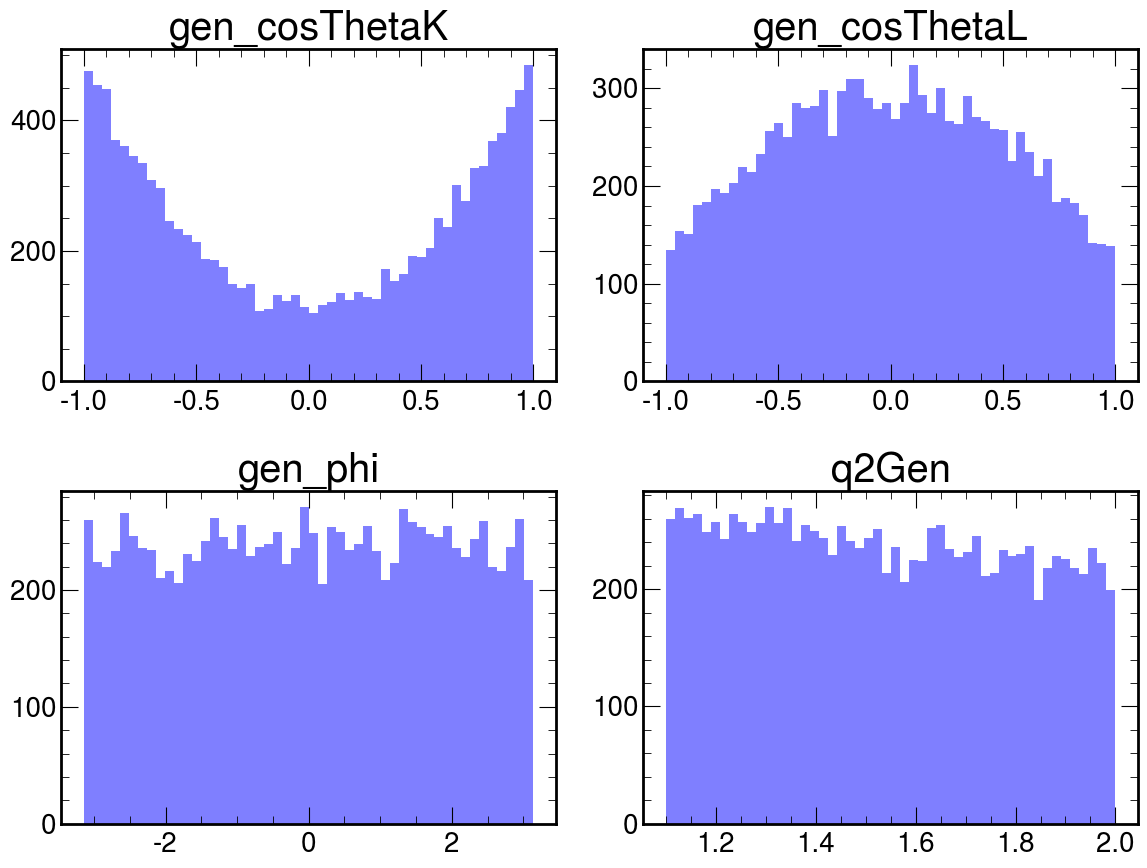


Procesando bin2 con rango q2: [2.0, 4.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin2/fit_results_gen_physical_slsqp_bin2.json
[0.5980919342034957, -0.06563298628649687, 0.0269162418051531, -0.015029064862111724, -0.5070989866907327, 0.004370158936912021, 0.022011925858035873, 0.014429091198364]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin2             0.598091  -  0.011   +  0.011       False
rS3_bin2           -0.0656322  -  0.048   +  0.048       False
rS9_bin2            0.0269154  -  0.047   +  0.047       False
rAFB_bin2           -0.015029  -  0.021   +  0.021       False
rS4_bin2            -0.507096  -  0.044   +  0.042       False
rS7_bin2           0.00436903  -  0.018   +  0.018       False
rS5_bin2            0.0220143  -  0.017   +  0.017       False
rS8_bin2            0.0144313  -  0.034   +  0.034    

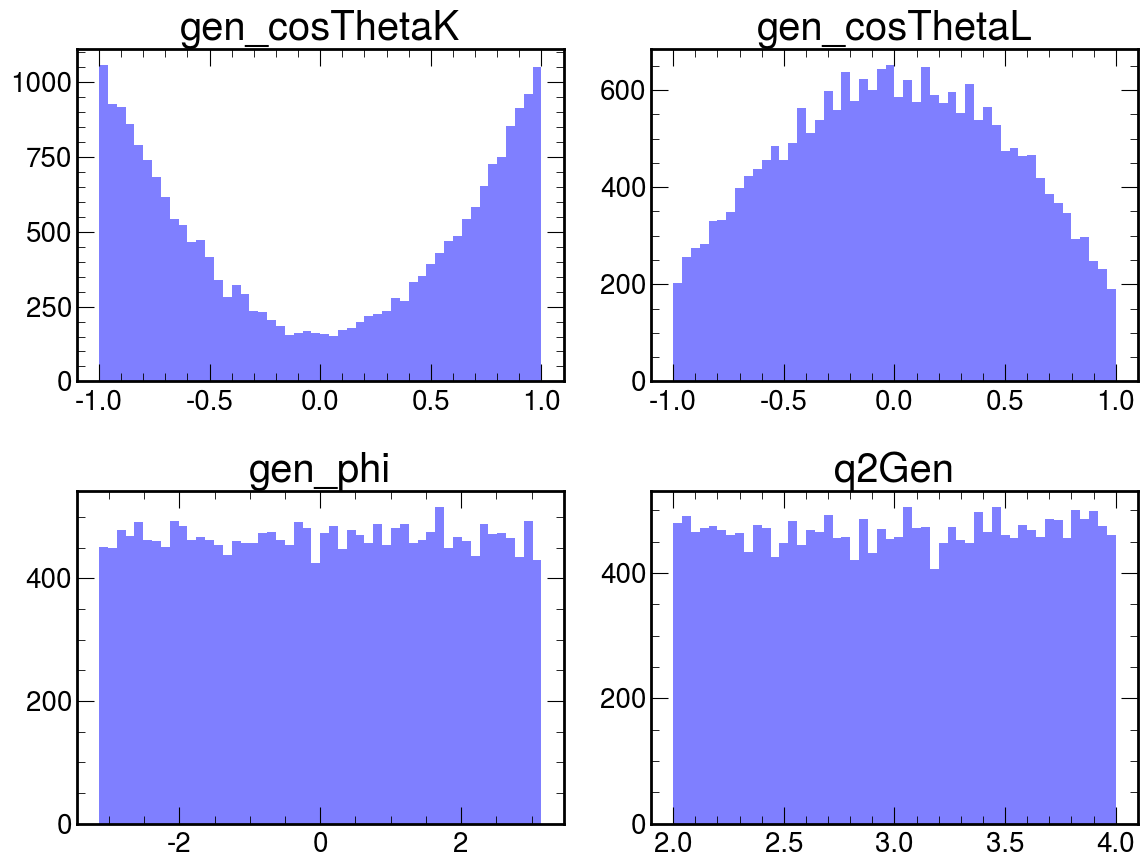


Procesando bin3 con rango q2: [4.0, 6.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin3/fit_results_gen_physical_slsqp_bin3.json
[0.42155167296287643, -0.06951071670117559, 0.04907317860209475, -0.01129249864973276, -1.324828089836051, 0.03942036092123545, -0.021478238322838406, 0.009108330554175807]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin3             0.421553  - 0.0097   + 0.0098       False
rS3_bin3            -0.069512  -  0.037   +  0.037       False
rS9_bin3            0.0490753  -  0.037   +  0.037       False
rAFB_bin3          -0.0112923  -  0.017   +  0.017       False
rS4_bin3             -1.32484  -   0.15   +   0.12       False
rS7_bin3            0.0394192  -  0.029   +   0.03       False
rS5_bin3            -0.021478  -  0.015   +  0.015       False
rS8_bin3           0.00910539  -  0.031   +  0.031 

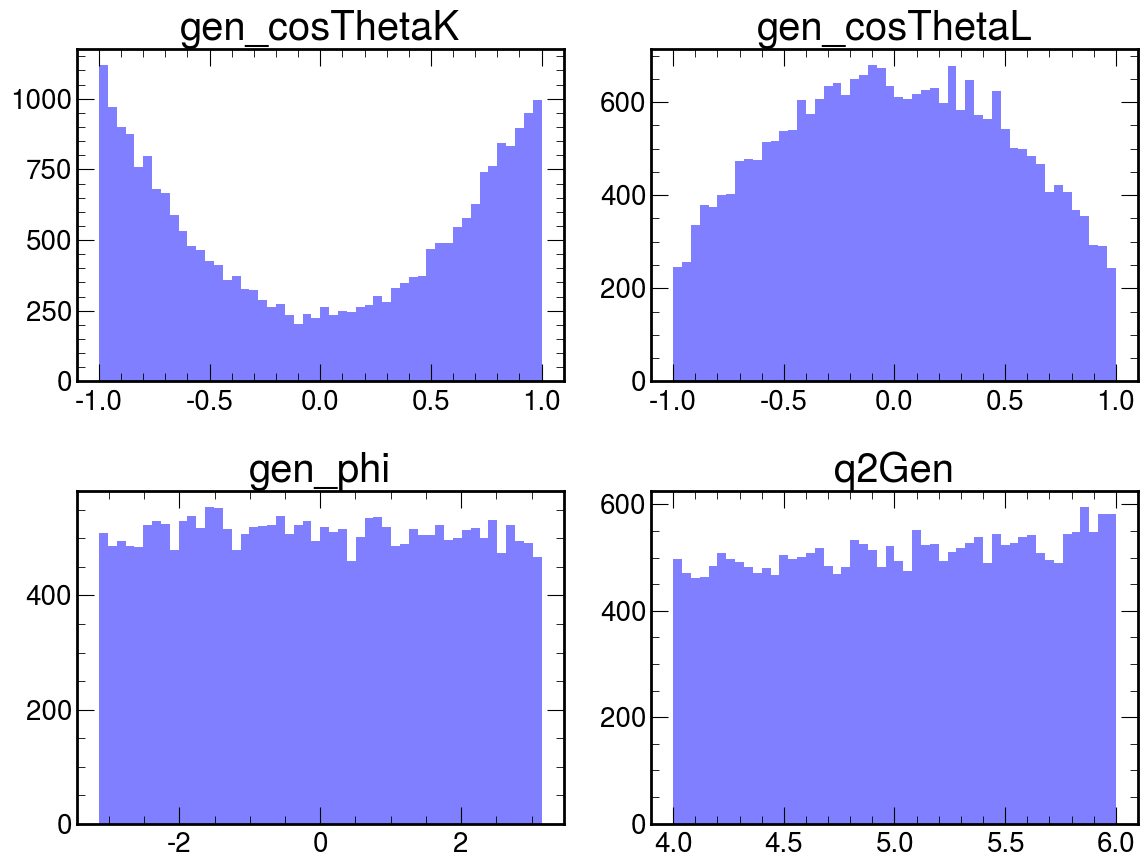


Procesando bin4 con rango q2: [6.0, 7.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin4/fit_results_gen_physical_slsqp_bin4.json
[0.23899358250746236, -0.08966075037972578, -0.005979313947521238, -0.016998516758512078, -1.7323398714279836, 0.01998926289263996, 0.017685915801794457, -0.04598492639904315]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin4             0.238993  -  0.012   +  0.012       False
rS3_bin4           -0.0896605  -  0.041   +  0.041       False
rS9_bin4          -0.00597885  -   0.04   +   0.04       False
rAFB_bin4          -0.0169981  -  0.019   +  0.019       False
rS4_bin4             -1.73234  -   0.52   +   0.25       False
rS7_bin4            0.0199888  -  0.051   +  0.057       False
rS5_bin4             0.017686  -  0.018   +  0.018       False
rS8_bin4           -0.0459841  -  0.039   +  0.0

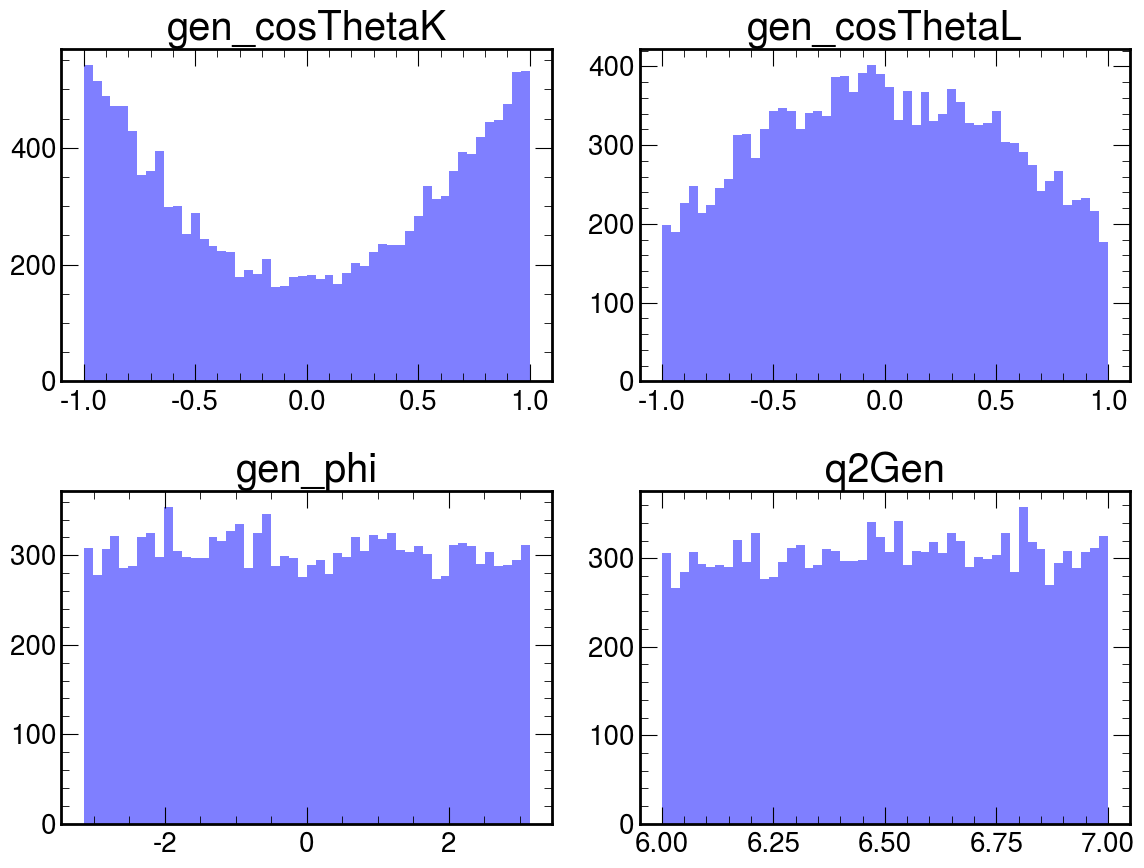


Procesando bin5 con rango q2: [7.0, 8.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin5/fit_results_gen_physical_slsqp_bin5.json
[0.1534771044572167, -0.10799743218635383, -0.008544594610385868, -0.023129007759547786, -1.8987555364686046, -0.039197418983198735, -0.009843263266441606, -0.0056410578075707036]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin5             0.153479  -  0.011   +  0.011       False
rS3_bin5            -0.107994  -  0.037   +  0.037       False
rS9_bin5          -0.00854067  -  0.037   +  0.037       False
rAFB_bin5          -0.0231259  -  0.017   +  0.017       False
rS4_bin5              -1.8987  -   0.92   +   0.31       False
rS7_bin5           -0.0392073  -  0.089   +  0.057       False
rS5_bin5          -0.00984058  -  0.018   +  0.018       False
rS8_bin5          -0.00563208  -  0.037   + 

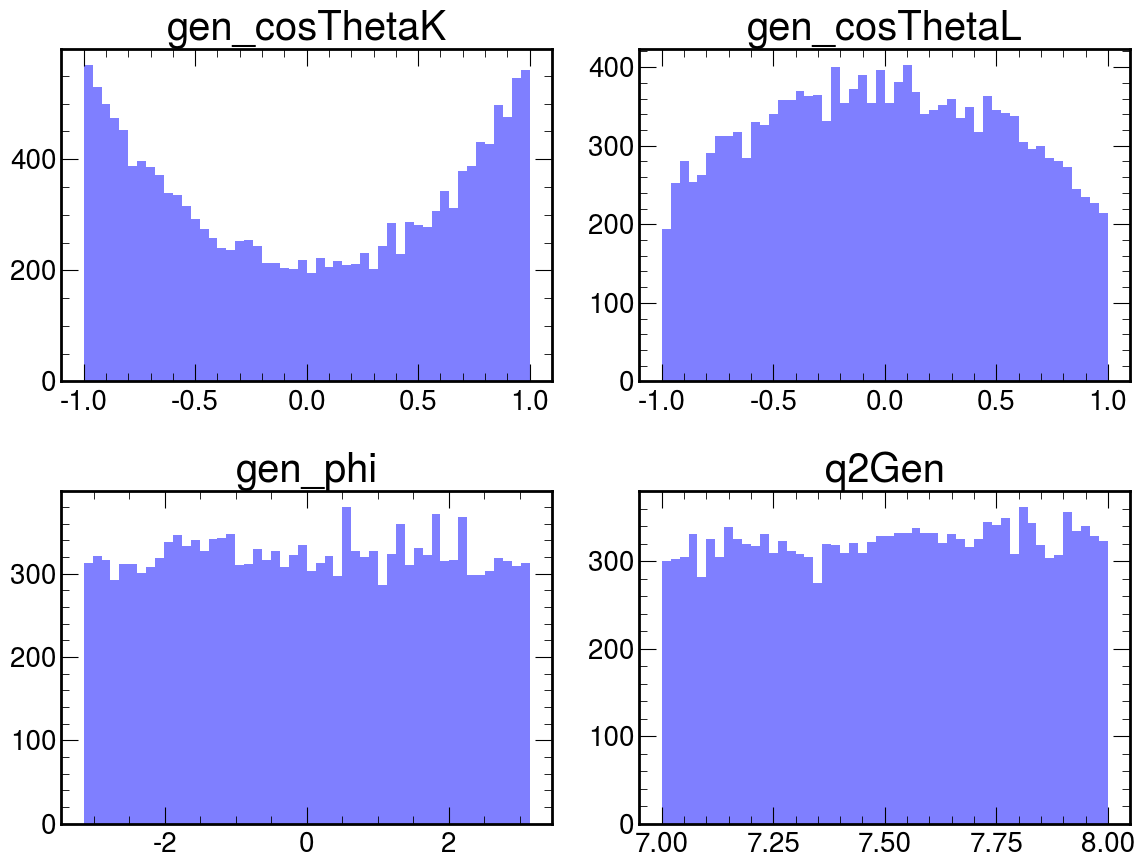


Procesando bin7 con rango q2: [11.0, 12.5]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin7/fit_results_gen_physical_slsqp_bin7.json
[-0.1310644245644679, -0.251399700266228, -0.014352360266897377, -0.005542996172277652, -1.8004736353486779, 0.03260796567817112, 0.02560183240380444, 0.05679236164549411]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin7            -0.131064  - 0.0085   + 0.0085       False
rS3_bin7            -0.251407  -  0.023   +  0.023       False
rS9_bin7           -0.0143583  -  0.023   +  0.023       False
rAFB_bin7         -0.00554206  -  0.011   +  0.011       False
rS4_bin7             -1.80046  -   0.31   +   0.19       False
rS7_bin7            0.0326292  -  0.036   +   0.04       False
rS5_bin7            0.0255986  -  0.014   +  0.014       False
rS8_bin7            0.0568015  -  0.031   +  0.031

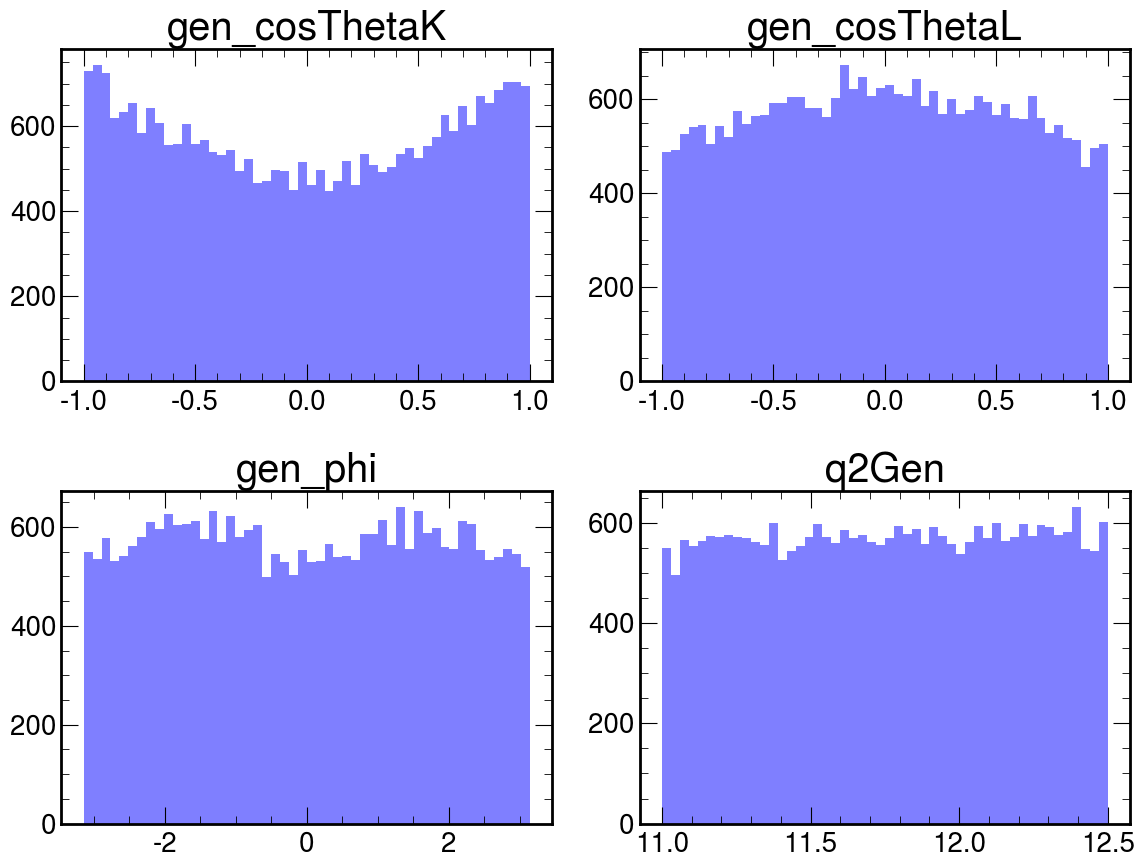


Procesando bin9 con rango q2: [15.0, 17.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin9/fit_results_gen_physical_slsqp_bin9.json
[-0.2910550540414604, -0.49392185699782376, 0.006414044231436055, -0.029629736206585888, -2.0033604479262466, 0.03189359653237642, 0.017224695105, 0.07390177926832484]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name         value  (rounded)                minos    at limit
---------  ------------------  -------------------  ----------
rFL_bin9            -0.291055  - 0.0084   + 0.0084       False
rS3_bin9            -0.493926  -  0.023   +  0.023       False
rS9_bin9           0.00641395  -  0.021   +  0.021       False
rAFB_bin9          -0.0296307  -   0.01   +   0.01       False
rS4_bin9             -2.00342  -   0.45   +   0.24       False
rS7_bin9            0.0318826  -   0.04   +  0.047       False
rS5_bin9            0.0172228  -  0.015   +  0.015       False
rS8_bin9            0.0739036  -  0.037   +  0.037    

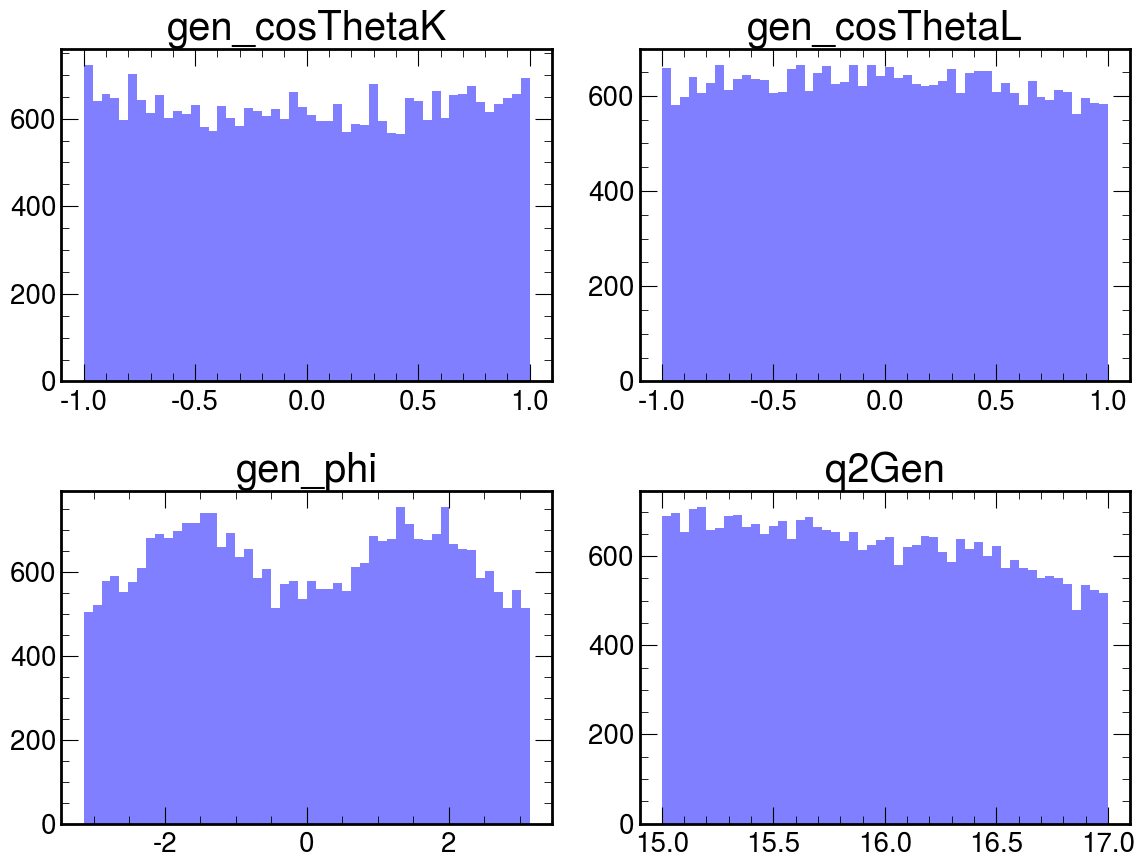


Procesando bin10 con rango q2: [17.0, 23.0]
-> Leyendo semillas iniciales de: fit_results/gen/gen_phy_slsqp/bin10/fit_results_gen_physical_slsqp_bin10.json
[-0.3250814714043656, -0.8167622831487216, -0.014975195809862929, 0.013735135907025872, -2.293720131234456, 0.012456309530223012, -0.02680251039455878, -0.006808443340326336]
NUMERO DE EVENTOS 347675 


>>> INICIANDO FIT GEN LEVEL 
name          value  (rounded)                minos    at limit
----------  ------------------  -------------------  ----------
rFL_bin10            -0.325082  -  0.011   +  0.011       False
rS3_bin10            -0.816759  -  0.041   +   0.04       False
rS9_bin10           -0.0149756  -  0.032   +  0.032       False
rAFB_bin10           0.0137357  -  0.016   +  0.016       False
rS4_bin10             -2.29372  -    0.6   +   0.39       False
rS7_bin10            0.0124549  -   0.11   +  0.065       False
rS5_bin10           -0.0268003  -  0.024   +  0.024       False
rS8_bin10          -0.00681001  -  

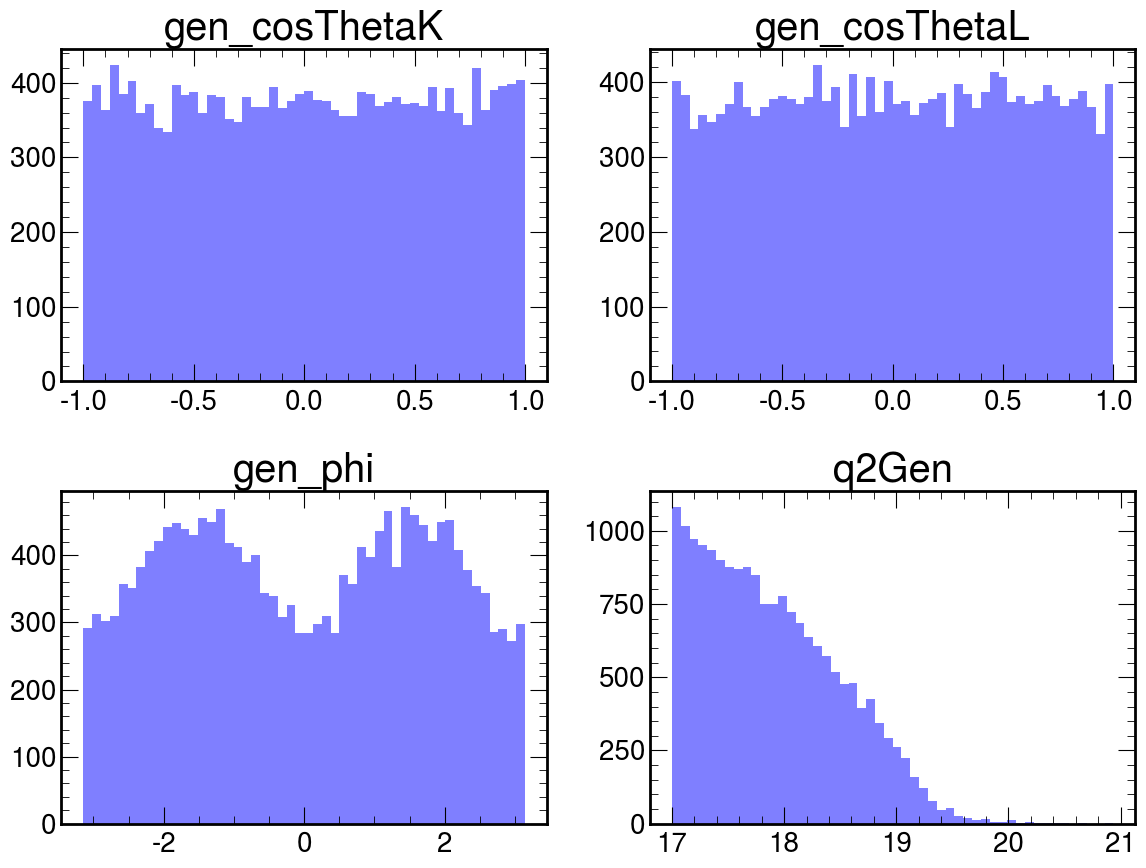

In [6]:

#%%capture data_gen_transformed_fit
sys.stdout = DuplicarSalida("fit_results/gen/gen_transformed_v1/results_fit_outpu.txt")
q2_bins = {"bin1":[1.1, 2.0],"bin2": [2.0, 4.0],"bin3":[4.0, 6.0], "bin4":[6.0, 7.0], "bin5":[7.0, 8.0],"bin7":[11.0, 12.5], "bin9":[15.0, 17.0], "bin10":[17.0, 23.0]}
#q2_bins = { "bin10":[17.0, 23.0]}

for binN in q2_bins.keys():
    print(f"\n{'='*60}\nProcesando {binN} con rango q2: {q2_bins[binN]}\n{'='*60}")
    # init_rFL, init_rS3 =0.5, 0.0
    # init_rS9, init_rAFB = 0.0, 0.0
    # init_rS4, init_rS7 = 0.0, 0.0
    # init_rS5, init_rS8 = 0.0, 0.0



    json_path = f"fit_results/gen/gen_phy_slsqp/{binN}/fit_results_gen_physical_slsqp_{binN}.json"
    print(f"-> Leyendo semillas iniciales de: {json_path}")
    with open(json_path, 'r') as file:
        data = json.load(file)
    params_dict = data.get("parameters", {})
    phys_params_list = [params_dict["FL"]["value"], params_dict["S3"]["value"], params_dict["S9"]["value"], params_dict["AFB"]["value"], params_dict["S4"]["value"], params_dict["S7"]["value"], params_dict["S5"]["value"], params_dict["S8"]["value"]]
    inv_vals = get_inverse_values(phys_params_list)
    print(inv_vals)
    init_rFL, init_rS3, init_rS9, init_rAFB, init_rS4, init_rS7, init_rS5, init_rS8 = inv_vals

    # ======================================================
    # CONFIGURACIÓN DEL ESPACIO 
    # ======================================================
    cos_l = zfit.Space('cos_l', limits=(-1, 1))
    cos_k = zfit.Space('cos_k', limits=(-1, 1))
    phi   = zfit.Space('phi',   limits=(-np.pi, np.pi)) 
    obs_ang = cos_l * cos_k * phi  
    lim_val = 10
    # rFL  = zfit.Parameter(f'rFL_{binN}',  init_rFL,  step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS3  = zfit.Parameter(f'rS3_{binN}',  init_rS3, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS9  = zfit.Parameter(f'rS9_{binN}',  init_rS9, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rAFB = zfit.Parameter(f'rAFB_{binN}', init_rAFB, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS4  = zfit.Parameter(f'rS4_{binN}',  init_rS4, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS7  = zfit.Parameter(f'rS7_{binN}',  init_rS7, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS5  = zfit.Parameter(f'rS5_{binN}',  init_rS5, step_size=1e-3,lower_limit=-lim_val, upper_limit=lim_val)
    # rS8  = zfit.Parameter(f'rS8_{binN}',  init_rS8, step_size=1e-3,lower_limit=-lim_val, upper_limit=lim_val)




    rFL  = zfit.Parameter(f'rFL_{binN}',  init_rFL,  step_size=1e-3)
    rS3  = zfit.Parameter(f'rS3_{binN}',  init_rS3, step_size=1e-3)
    rS9  = zfit.Parameter(f'rS9_{binN}',  init_rS9, step_size=1e-3)
    rAFB = zfit.Parameter(f'rAFB_{binN}', init_rAFB, step_size=1e-3)
    rS4  = zfit.Parameter(f'rS4_{binN}',  init_rS4, step_size=1e-3)
    rS7  = zfit.Parameter(f'rS7_{binN}',  init_rS7, step_size=1e-3)
    rS5  = zfit.Parameter(f'rS5_{binN}',  init_rS5, step_size=1e-3)
    rS8  = zfit.Parameter(f'rS8_{binN}',  init_rS8, step_size=1e-3)


    # r_keys = ['rFL', 'rS3', 'rS9', 'rAFB', 'rS4', 'rS7', 'rS5', 'rS8']
    fit_params_list = [rFL, rS3, rS9, rAFB, rS4, rS7, rS5, rS8]

    # ======================================================
    # CONSTRUCCIÓN DE PDFs Y CARGA DE DATOS
    # ======================================================
    # PDF  Transformada
    pdf_ang_trans = FullAngular_Transformed_PDF(obs_ang, rFL, rS3, rS9, rAFB, rS4, rS7, rS5, rS8)
    # Carga de Datos
    obs_Gen_q2 = select_q2_bin(obs_Gen, binN, "q2Gen")
    data_true = zfit.Data.from_numpy(array=obs_Gen_q2[["gen_cosThetaL", "gen_cosThetaK", "gen_phi"]].to_numpy(), obs=obs_ang)
    print(f"NUMERO DE EVENTOS {len(obs_Gen)} \n")

    # ======================================================
    # FITS
    # ======================================================
    print("\n" + "="*60)
    print(">>> INICIANDO FIT GEN LEVEL ")
    print("="*60)
    result_gen, errors_gen = run_fit(pdf_ang_trans, data_true)
    print(result_gen.params)
    
    # Extraer valores centrales y la matriz de covarianza de zfit
    r_values = np.array([result_gen.params[p]['value'] for p in fit_params_list])
    cov_fit = result_gen.covariance(params=fit_params_list)

    # ======================================================
    # PROPAGACIÓN DE ERRORES
    # ======================================================
    obs_order = ['FL', 'AFB', 'S3', 'S4', 'S5', 'S7', 'S8', 'S9']
    f_transform = lambda x: get_physical_array(obs_order=obs_order, r_array=x)
    J = compute_jacobian(f_transform, r_values)
    cov_phys = J @ cov_fit @ J.T
    errors_phys = np.sqrt(np.diag(cov_phys))
    phys_vals_gen_dict = apply_transformation_equations(*r_values)
    print("\n" + "-"*80)
    print(f"RESUMEN DE OBSERVABLES FÍSICOS (Bin: {binN})")
    print("-"*80)
    print(f"{'Observable':<10} | {'Valor Físico':<15} | {'Error':<25}")
    print("-"*80)

    for i, key in enumerate(obs_order):
        val = phys_vals_gen_dict.get(key, 0.0)
        err = errors_phys[i]
        print(f"{key:<10} | {val:>15.6f} | +/- {err:<15.6f}")
    print("-"*80 + "\n")
    
    # =============
    # SAVE INFO
    # =============
    save_fit_results(result_gen, binN, base_dir="fit_results/gen/gen_transformed_v1", name=f"fit_results_gen_transformed_v1_{binN}")
    save_phy_results(result_zfit=result_gen, phys_dict=phys_vals_gen_dict, cov_phys=cov_phys, obs_order=obs_order, bin_n=binN, base_dir="fit_results/gen/gen_transformed_v1", name=f"fit_results_gen_transformed_v1_phy_{binN}")
    #plot_nll_profiles(result_gen, fit_params_list, binN,base_dir=f"fit_results/gen/gen_transformed_v1/{binN}/nll_profiles")
    save_correlation_matrix(result_gen, fit_params_list, binN, out_dir=f"fit_results/gen/gen_transformed_v1/{binN}")
    contour_out_dir = f"fit_results/gen/gen_transformed_v1/{binN}/"
    #generate_contours(pdf=pdf_ang_trans, data=data_true, fit_params_list=fit_params_list, result_zfit=result_gen, binN=binN, out_dir=contour_out_dir)
    # plot_analytical_projections_cms(sampler=data_true, phys_params_dict=phys_vals_gen_dict, folder_out=f"fit_results/gen/gen_transformed_v1/{binN}/projections", n_bins=30)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # Histograma para gen_cosThetaK
    axes[0, 0].hist(obs_Gen_q2['gen_cosThetaK'], bins=50, color='b', alpha = 0.5)
    axes[0, 0].set_title('gen_cosThetaK')

    # Histograma para gen_cosThetaL
    axes[0, 1].hist(obs_Gen_q2['gen_cosThetaL'], bins=50, color='b', alpha = 0.5)
    axes[0, 1].set_title('gen_cosThetaL')

    # Histograma para gen_phi
    axes[1, 0].hist(obs_Gen_q2['gen_phi'], bins=50, color='b', alpha = 0.5)
    axes[1, 0].set_title('gen_phi')

    # Histograma para q2Gen
    axes[1, 1].hist(obs_Gen_q2['q2Gen'], bins=50, color='b',alpha = 0.5)
    axes[1, 1].set_title('q2Gen')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
sys.stdout.log.close()
sys.stdout = sys.stdout.terminal

    

# RECO FIT TRANSFORMED V1 (EFFICIENCY)

In [7]:
#%%capture mi_registro
#q2_bins = {"bin1":[1.1, 2.0],"bin2": [2.0, 4.0],"bin3":[4.0, 6.0], "bin4":[6.0, 7.0], "bin5":[7.0, 8.0],"bin7":[11.0, 12.5], "bin9":[15.0, 17.0], "bin10":[17.0, 23.0]}

q2_bins = {"bin1":[1.1, 2.0]}



for binN in q2_bins.keys():
    print(f"\n{'='*60}\nProcesando {binN} con rango q2: {q2_bins[binN]}\n{'='*60}")


    json_path = f"fit_results/reco/reco_phy_slsqp/{binN}/fit_results_reco_physical_slsqp_{binN}.json"
    print(f"-> Leyendo semillas iniciales de: {json_path}")
    with open(json_path, 'r') as file:
        data = json.load(file)
    params_dict = data.get("parameters", {})
    phys_params_list = [params_dict["FL"]["value"], params_dict["S3"]["value"], params_dict["S9"]["value"], params_dict["AFB"]["value"], params_dict["S4"]["value"], params_dict["S7"]["value"], params_dict["S5"]["value"], params_dict["S8"]["value"]]
    inv_vals = get_inverse_values(phys_params_list)
    print(inv_vals)
    init_rFL_reco, init_rS3_reco, init_rS9_reco, init_rAFB_reco, init_rS4_reco, init_rS7_reco, init_rS5_reco, init_rS8_reco = inv_vals
    # ======================================================
    # CONFIGURACIÓN DEL ESPACIO 
    # ======================================================
    cos_l = zfit.Space('cos_l', limits=(-1, 1))
    cos_k = zfit.Space('cos_k', limits=(-1, 1))
    phi   = zfit.Space('phi',   limits=(-np.pi, np.pi)) 
    obs_ang = cos_l * cos_k * phi  

    lim_val = 5
    # rFL  = zfit.Parameter(f'rFL_{binN}_reco',  0.5,step_size=1e-3,lower_limit=-lim_val, upper_limit=lim_val)
    # rS3  = zfit.Parameter(f'rS3_{binN}_reco',  1e-1, step_size=1e-3,lower_limit=-lim_val, upper_limit=lim_val)
    # rS9  = zfit.Parameter(f'rS9_{binN}_reco',  1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rAFB = zfit.Parameter(f'rAFB_{binN}_reco', 1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS4  = zfit.Parameter(f'rS4_{binN}_reco',  1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS7  = zfit.Parameter(f'rS7_{binN}_reco',  1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS5  = zfit.Parameter(f'rS5_{binN}_reco',  1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    # rS8  = zfit.Parameter(f'rS8_{binN}_reco',  1e-1, step_size=1e-3, lower_limit=-lim_val, upper_limit=lim_val)
    rFL  = zfit.Parameter(f'rFL_{binN}_reco',  init_rFL_reco,  step_size=1e-3)
    rS3  = zfit.Parameter(f'rS3_{binN}_reco',  init_rS3_reco, step_size=1e-3)
    rS9  = zfit.Parameter(f'rS9_{binN}_reco',  init_rS9_reco, step_size=1e-3)
    rAFB = zfit.Parameter(f'rAFB_{binN}_reco', init_rAFB_reco, step_size=1e-3)
    rS4  = zfit.Parameter(f'rS4_{binN}_reco',  init_rS4_reco, step_size=1e-3)
    rS7  = zfit.Parameter(f'rS7_{binN}_reco',  init_rS7_reco, step_size=1e-3)
    rS5  = zfit.Parameter(f'rS5_{binN}_reco',  init_rS5_reco, step_size=1e-3)
    rS8  = zfit.Parameter(f'rS8_{binN}_reco',  init_rS8_reco, step_size=1e-3)
    # Listas auxiliares
    # # Listas auxiliares
    #r_keys = ['rFL', 'rS3', 'rS9', 'rAFB', 'rS4', 'rS7', 'rS5', 'rS8']
    fit_params_list = [rFL, rS3, rS9, rAFB, rS4, rS7, rS5, rS8]

    # ======================================================
    # CONSTRUCCIÓN DE PDFs Y CARGA DE DATOS
    # ======================================================

    # PDF  Transformada
    pdf_ang_trans = FullAngular_Transformed_PDF(obs_ang, rFL, rS3, rS9, rAFB, rS4, rS7, rS5, rS8)

    # PDF de Eficiencia
    coef_acc, nx_acc, ny_acc = load_bernstein_model(f"efficiency_models/{binN}/acc_gen_model_{binN}.json")
    coef_acc_phi, n_phi_acc = load_bernstein1d_model(f"efficiency_models/{binN}/acc_gen_model_phi_{binN}.json")

    coef_reco, nx_reco, ny_reco = load_bernstein_model(f"efficiency_models/{binN}/eff_reco_model_{binN}.json")
    coef_reco_phi, n_phi_reco = load_bernstein1d_model(f"efficiency_models/{binN}/eff_reco_model_phi_{binN}.json")

    eff_pdf = Efficiency_Bernstein_Factorized(
        obs=obs_ang, coef_acc_2d=coef_acc, coef_acc_phi=coef_acc_phi, nx_acc=nx_acc, ny_acc=ny_acc, n_phi_acc=n_phi_acc,
        coef_reco_2d=coef_reco, coef_reco_phi=coef_reco_phi,nx_reco=nx_reco, ny_reco=ny_reco, n_phi_reco=n_phi_reco, name=f"Eff_Model_{binN}")
    pdf_sig = zfit.pdf.ProductPDF([pdf_ang_trans, eff_pdf])


    # Carga de Datos
    obs_RecoFtr_q2 = select_q2_bin(obs_RecoFtr, binN, "q2")
    data_reco = zfit.Data.from_numpy(array=obs_RecoFtr_q2[["CosThetaL", "CosThetaK", "Phi"]].to_numpy(), obs=obs_ang)
    

    print("\n" + "="*60)
    print(">>> INICIANDO FIT RECO)")
    print("="*60)
    for p in fit_params_list: p.set_value(0.01)    
    pdf_sig.update_integration_options(max_draws=200000, tol=1e-5)
    result_reco, errors_reco = run_fit(pdf_sig, data_reco)
    print("\n" + "="*60)
    print(">>> RESULTADOS FINALES DEL FIT RECO")
    print("="*60)
    print(result_reco)
    

    # # callculo y tabla de Observables Físicos para RECO
    # r_values_reco = [result_reco.params[p]['value'] for p in fit_params_list]
    # phys_vals_reco = apply_transformation_equations(*r_values_reco)
    # print("\n" + "-"*60)
    # print(f"RESUMEN DE OBSERVABLES FÍSICOS RECO (Bin: {binN})")
    # print("-"*60)
    # print(f"{'Observable':<10} | {'Valor Físico':<15}")
    # print("-"*60)
    # print_order = ['FL', 'AFB', 'S3', 'S4', 'S5', 'S7', 'S8', 'S9']    
    # for key in print_order:
    #     val = phys_vals_reco.get(key, 0.0)
    #     print(f"{key:<10} | {val:>15.6f}")
    # print("-"*60 + "\n")


    # ======================================================
    # PROPAGACIÓN DE ERRORES
    # ======================================================
    # Extraer valores centrales y la matriz de covarianza de zfit
    r_values = np.array([result_reco.params[p]['value'] for p in fit_params_list])
    cov_fit = result_reco.covariance(params=fit_params_list)
    obs_order = ['FL', 'AFB', 'S3', 'S4', 'S5', 'S7', 'S8', 'S9']
    f_transform = lambda x: get_physical_array(obs_order=obs_order, r_array=x)
    J = compute_jacobian(f_transform, r_values)
    cov_phys = J @ cov_fit @ J.T
    errors_phys = np.sqrt(np.diag(cov_phys))
    phys_vals_reco_dict = apply_transformation_equations(*r_values)
    print("\n" + "-"*80)
    print(f"RESUMEN DE OBSERVABLES FÍSICOS (Bin: {binN})")
    print("-"*80)
    print(f"{'Observable':<10} | {'Valor Físico':<15} | {'Error':<25}")
    print("-"*80)

    for i, key in enumerate(obs_order):
        val = phys_vals_reco_dict.get(key, 0.0)
        err = errors_phys[i]
        print(f"{key:<10} | {val:>15.6f} | +/- {err:<15.6f}")
    print("-"*80 + "\n")
    


     
    # =============
    # SAVE INFO
    # =============
    save_fit_results(result_reco, binN, base_dir="fit_results/reco/reco_transformed_v1", name=f"fit_results_reco_transformed_v1_{binN}")
    save_phy_results(result_zfit=result_reco, phys_dict=phys_vals_reco_dict, cov_phys=cov_phys, obs_order=obs_order, bin_n=binN, base_dir="fit_results/reco/reco_transformed_v1", name=f"fit_results_reco_transformed_v1_phy_{binN}")
    #plot_nll_profiles(result_reco, fit_params_list, binN,base_dir=f"fit_results/reco/reco_transformed_v1/{binN}/nll_profiles")
    save_correlation_matrix(result_reco, fit_params_list, binN, out_dir=f"fit_results/reco/reco_transformed_v1/{binN}")
    contour_out_dir = f"fit_results/reco/reco_transformed_v1/{binN}/"
    generate_contours(pdf=pdf_sig, data=data_reco, fit_params_list=fit_params_list, result_zfit=result_reco, binN=binN, out_dir=contour_out_dir)
    plot_analytical_projections_cms(sampler=data_reco, phys_params_dict=phys_vals_reco_dict, folder_out=f"fit_results/reco/reco_transformed_v1/{binN}/projections", n_bins=30)
    save_correlation_matrix(result_reco, fit_params_list, binN, out_dir=f"fit_results/reco/reco_transformed_v1/{binN}")

    


Procesando bin1 con rango q2: [1.1, 2.0]
-> Leyendo semillas iniciales de: fit_results/reco/reco_phy_slsqp/bin1/fit_results_reco_physical_slsqp_bin1.json
[0.3360402972135212, 0.06791884060777885, -0.03665991310702795, 0.058080870193259686, -0.4597168300474789, 0.09298295571931113, 0.004783454370106235, -0.11670790345105012]

>>> INICIANDO FIT RECO)


2026-03-19 20:39:40.806627: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-19 20:39:41.383402: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-19 20:39:41.384468: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf


>>> RESULTADOS FINALES DEL FIT RECO
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.functor.ProductPDF'>  params=[]] data=[<zfit.core.data.Data object at 0x77661eb0ed30>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | internal) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════════╡
│  True   │    True     │      False       │ 7.8e-05 │             37768.69 |  9673.755 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════════╛

Parameters
name              value  (rounded)                minos    at limit
--------------  ------------------  -------------------  ----------
rFL_bin1_reco             0.331917  -  0.014   +  0.014       False
rS3_bin1_reco            0.0122612  -  0.034   +  0.033       False
rS9_bin1_reco           -0.0427552